# Демонстрации к лекции 5: метод Ньютона, BFGS и Гаусс–Ньютон

Ноутбук — для самостоятельной проверки после пары: всё, что на лекции было формулой или картинкой, здесь считается кодом, а числа конспекта воспроизводятся и печатаются рядом с ожидаемыми. Читается сверху вниз; каждая часть начинается с «что проверяем и что должны увидеть». Разминка и четыре части:

- **(0)** три задачи лекции (разделы 1 и 6 конспекта): Розенброк, подгонка синуса из ДЗ 2, цепь без пола — данные, функции, производные;
- **(a)** метод Ньютона на Розенброке (разделы 2–3): $7$ итераций, таблица ошибок и квадратичная сходимость, выброс на итерации 2, демпфирование по правилу Армихо — $22$ итерации;
- **(b)** BFGS (раздел 4): два обновления на квадратичной восстанавливают $Q^{-1}$; Розенброк — $34$ итерации против $33$ у SciPy; сверхлинейная сходимость; L-BFGS;
- **(c)** Гаусс–Ньютон на синусе (раздел 5): $7$ итераций против $731$ у спуска; почему Ньютон уходит в $x_1=0$; Левенберг–Марквардт; 20 стартов ДЗ 2;
- **(d)** биография цепи (раздел 6): спуск $10\,575$, Ньютон — один `solve`, BFGS с точным шагом $20$, L-BFGS $75$; и как BFGS ломается с одним лишь правилом Армихо.

Конспект: [`lecture05.md`](lecture05.md). Запуск: `uv run jupyter lab` в корне репозитория. Пакеты — `numpy`, `scipy`, `matplotlib`.

In [1]:
%matplotlib inline

import time

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, least_squares

BLUE, ORANGE, AQUA, RED, VIOLET, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#e34948", "#4a3aa7", "#8a8985", "#0b0b0b"
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.2, "legend.frameon": False})


# ---------------------------------------------------------------- методы
def gd(f, grad, x0, alpha=None, tol=1e-6, maxit=100_000, c=1e-4):
    """Градиентный спуск (лекция 4): alpha=None — backtracking по Армихо с константой c,
    иначе постоянный шаг. Возвращает (x, число итераций, путь (k+1, n))."""
    x = np.asarray(x0, float).copy(); path = [x.copy()]
    for k in range(maxit):
        g = grad(x)
        if np.linalg.norm(g) <= tol:
            return x, k, np.array(path)
        if alpha is None:
            a, fx = 1.0, f(x)
            while f(x - a * g) > fx - c * a * (g @ g):
                a /= 2
        else:
            a = alpha
        x = x - a * g; path.append(x.copy())
    return x, maxit, np.array(path)


def newton(grad, hess, x0, tol=1e-10, maxit=50):
    """Чистый метод Ньютона: x <- x - H^{-1} g, длина шага всегда 1. Возвращает (x, итераций, путь)."""
    x = np.asarray(x0, float).copy(); path = [x.copy()]
    for k in range(maxit):
        g = grad(x)
        if np.linalg.norm(g) <= tol:
            return x, k, np.array(path)
        x = x - np.linalg.solve(hess(x), g); path.append(x.copy())
    return x, maxit, np.array(path)


def newton_damped(f, grad, hess, x0, tol=1e-10, maxit=200, c=1e-4):
    """Демпфированный Ньютон: направление Ньютона, длина шага — по правилу Армихо.
    Если гессиан индефинитен и направление не является спуском, матрица
    сдвигается: H + (|lambda_min| + 1e-3) I. Возвращает (x, итераций, путь)."""
    x = np.asarray(x0, float).copy(); path = [x.copy()]
    for k in range(maxit):
        g = grad(x)
        if np.linalg.norm(g) <= tol:
            return x, k, np.array(path)
        H = hess(x)
        p = -np.linalg.solve(H, g)
        if g @ p >= 0:                                   # не спуск: сдвигаем собственные числа
            lam_min = np.linalg.eigvalsh(H)[0]
            p = -np.linalg.solve(H + (abs(lam_min) + 1e-3) * np.eye(len(x)), g)
        a, fx = 1.0, f(x)
        while f(x + a * p) > fx + c * a * (g @ p):
            a /= 2
        x = x + a * p; path.append(x.copy())
    return x, maxit, np.array(path)


def bfgs(f, grad, x0, tol=1e-6, maxit=10_000, c=1e-4, Q=None):
    """BFGS с H_0 = I: p = -H g, обновление обратного гессиана по паре (s, y).
    Длина шага: backtracking по Армихо (Q=None) или точный шаг на квадратичной
    1/2 x^T Q x + b^T x (передать Q). Возвращает (x, итераций, путь, число вычислений f)."""
    x = np.asarray(x0, float).copy(); n = len(x)
    H = np.eye(n); path = [x.copy()]; g = grad(x); nfev = 1
    for k in range(maxit):
        if np.linalg.norm(g) <= tol:
            return x, k, np.array(path), nfev
        p = -H @ g
        if Q is None:
            a, fx = 1.0, f(x)
            while f(x + a * p) > fx + c * a * (g @ p):
                a /= 2; nfev += 1
            nfev += 1
        else:
            a = -(g @ p) / (p @ Q @ p)
        s = a * p; x_new = x + s; g_new = grad(x_new); y = g_new - g
        if s @ y > 1e-12:                                # условие кривизны: иначе H не обновляем
            rho = 1.0 / (s @ y); I = np.eye(n)
            H = (I - rho * np.outer(s, y)) @ H @ (I - rho * np.outer(y, s)) + rho * np.outer(s, s)
        x, g = x_new, g_new; path.append(x.copy())
    return x, maxit, np.array(path), nfev


def gauss_newton(resid, jac, x0, tol=1e-6, maxit=100, damped=False, c=1e-4):
    """Гаусс–Ньютон для f = 1/2 ||r(x)||^2: шаг — решение линейного МНК min ||J p + r||
    (np.linalg.lstsq). damped=True — backtracking по Армихо. Возвращает (x, итераций, путь)."""
    x = np.asarray(x0, float).copy(); path = [x.copy()]
    for k in range(maxit):
        r = resid(x); J = jac(x); g = J.T @ r
        if np.linalg.norm(g) <= tol:
            return x, k, np.array(path)
        p = np.linalg.lstsq(J, -r, rcond=None)[0]
        a = 1.0
        if damped:
            fx = 0.5 * (r @ r)
            while 0.5 * np.sum(resid(x + a * p) ** 2) > fx + c * a * (g @ p) and a > 1e-10:
                a /= 2
        x = x + a * p; path.append(x.copy())
    return x, maxit, np.array(path)


# ---------------------------------------------------------------- задачи
def rosen(x):
    return (1 - x[0]) ** 2 + 100 * (x[1] - x[0] ** 2) ** 2


def rosen_grad(x):
    return np.array([-2 * (1 - x[0]) - 400 * x[0] * (x[1] - x[0] ** 2), 200 * (x[1] - x[0] ** 2)])


def rosen_hess(x):
    return np.array([[2 - 400 * x[1] + 1200 * x[0] ** 2, -400 * x[0]], [-400 * x[0], 200.0]])


X0_ROSEN = np.array([-1.2, 1.0])


def make_chain(N, D=70.0, g=9.81):
    """Цепь без пола (лекция 1, §7.3): E(v) = 1/2 v^T H v + b^T v + const, v = (y_1..y_N, z_1..z_N).
    Возвращает (energy, grad_E, H, b, v0, unpack); unpack(v) -> (y, z) с закреплёнными концами."""
    m = 4.0 / N
    K = 2 * np.eye(N) - np.eye(N, k=1) - np.eye(N, k=-1)
    H = np.kron(np.eye(2), D * K)
    b = np.zeros(2 * N)
    b[0] -= D * (-2.0); b[N - 1] -= D * 2.0
    b[N] -= D * 1.0; b[2 * N - 1] -= D * 1.0
    b[N:] += m * g
    v0 = np.r_[np.linspace(-2, 2, N + 2)[1:-1], np.ones(N)]       # старт: прямая между концами

    def unpack(v):
        return np.r_[-2.0, v[:N], 2.0], np.r_[1.0, v[N:], 1.0]

    def energy(v):
        y, z = unpack(v)
        return 0.5 * D * np.sum(np.diff(y) ** 2 + np.diff(z) ** 2) + m * g * np.sum(z[1:-1])

    def grad_E(v):
        return H @ v + b
    return energy, grad_E, H, b, v0, unpack


def sine_data():
    """Данные задачи 2(б) ДЗ 2: y = 2 sin(3t + 0.7) + шум, 60 точек, тот же генератор и порядок вызовов.
    Возвращает (t, y, starts) — starts: 20 стартов ДЗ 2 в [-5, 5]^3."""
    data_rng = np.random.default_rng(2026)
    N, omega = 60, 3.0
    t = np.sort(data_rng.uniform(0, 2 * np.pi, N))
    y = 2.0 * np.sin(3.0 * t + 0.7) + 0.2 * data_rng.standard_normal(N)
    starts = data_rng.uniform(-5, 5, (20, 3))
    return t, y, starts


def sine_problem(t, y):
    """Модель x1 sin(x2 t + x3). Возвращает (resid, jac, f, grad, hess): невязки, якобиан невязок,
    f = 1/2 ||r||^2, градиент J^T r и полный гессиан J^T J + sum r_i hess(r_i)."""
    def resid(x):
        return x[0] * np.sin(x[1] * t + x[2]) - y

    def jac(x):
        s, c = np.sin(x[1] * t + x[2]), np.cos(x[1] * t + x[2])
        return np.c_[s, x[0] * t * c, x[0] * c]

    def f(x):
        r = resid(x); return 0.5 * (r @ r)

    def grad(x):
        return jac(x).T @ resid(x)

    def hess(x):
        J, r = jac(x), resid(x)
        s, c = np.sin(x[1] * t + x[2]), np.cos(x[1] * t + x[2])
        S = np.zeros((3, 3))                            # сумма r_i * hess(r_i) — то, что отбрасывает Гаусс–Ньютон
        S[0, 1] = S[1, 0] = r @ (t * c); S[0, 2] = S[2, 0] = r @ c
        S[1, 1] = r @ (-x[0] * t ** 2 * s); S[1, 2] = S[2, 1] = r @ (-x[0] * t * s); S[2, 2] = r @ (-x[0] * s)
        return J.T @ J + S
    return resid, jac, f, grad, hess


X0_SINE = np.array([1.0, 3.0, 0.0])


# ---------------------------------------------------------------- рисовальщики: принимают ax=None, возвращают ax
def plot_rosen_path(paths, labels=None, ax=None, xlim=(-2.2, 2.2), ylim=(-3.5, 3.2), every=1):
    """Линии уровня Розенброка и пути методов. paths — список массивов (k+1, 2); labels — подписи;
    every — прореживание длинных путей (каждая every-я точка). Возвращает ax."""
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))
    X, Y = np.meshgrid(np.linspace(*xlim, 400), np.linspace(*ylim, 400))
    ax.contour(X, Y, (1 - X) ** 2 + 100 * (Y - X ** 2) ** 2, levels=np.logspace(-1, 3.3, 14), colors=[GRAY], linewidths=0.7)
    colors = [ORANGE, VIOLET, AQUA, BLUE, RED]
    for i, p in enumerate(paths):
        pp = p if len(p) <= 60 else np.r_[p[:30], p[30::every]]
        lab = None if labels is None else labels[i]
        ax.plot(pp[:, 0], pp[:, 1], "-o", ms=3 if len(p) > 60 else 4.5, lw=1.3, color=colors[i % len(colors)], label=lab)
    ax.plot(1, 1, "*", ms=13, color=RED, mec="white", zorder=7)
    ax.set(xlim=xlim, ylim=ylim, xlabel="$x_1$", ylabel="$x_2$"); ax.grid(False)
    if labels is not None:
        ax.legend(loc="upper left", fontsize=8)
    return ax


def plot_errors(errs, labels=None, ax=None, logx=False):
    """График log10 ошибки по итерациям для нескольких методов. errs — список массивов ||e_k||.
    logx=True — логарифмическая ось итераций (когда методы отличаются на порядки). Возвращает ax."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6.5, 4.2))
    colors = [ORANGE, VIOLET, AQUA, BLUE, RED]
    for i, e in enumerate(errs):
        k = np.arange(1, len(e) + 1) if logx else np.arange(len(e))
        lab = None if labels is None else labels[i]
        ax.plot(k, np.log10(np.asarray(e) + 1e-17), "-o" if len(e) < 60 else "-", ms=3.5, lw=1.4, color=colors[i % len(colors)], label=lab)
    if logx:
        ax.set_xscale("log")
    ax.set(xlabel="итерация $k$" + (" (лог. шкала)" if logx else ""), ylabel="$\\log_{10}\\Vert x_k-x^*\\Vert$")
    if labels is not None:
        ax.legend(fontsize=8)
    return ax

## (0) Три задачи лекции

Разделы 1 и 6 конспекта. Здесь только определяем задачи и смотрим на данные; числа конспекта, которые проверим в частях (a)–(d): Розенброк — спуск $13\,756$, Ньютон $7$; синус — спуск $731$, Ньютон уходит в $x_1=0$; цепь — спуск $10\,575$, Ньютон $1$.

**Задача А. Розенброк** $f(x)=(1-x_1)^2+100(x_2-x_1^2)^2$, старт $(-1.2,\,1)$ — как в лекции 4. Гессиан $\begin{pmatrix}2-400x_2+1200x_1^2&-400x_1\\-400x_1&200\end{pmatrix}$; в старте он положительно определён — проверяем по собственным числам.

f(x0) = 24.2   grad = [-215.6  -88. ]   собственные числа гессиана: [  23.63 1506.37]


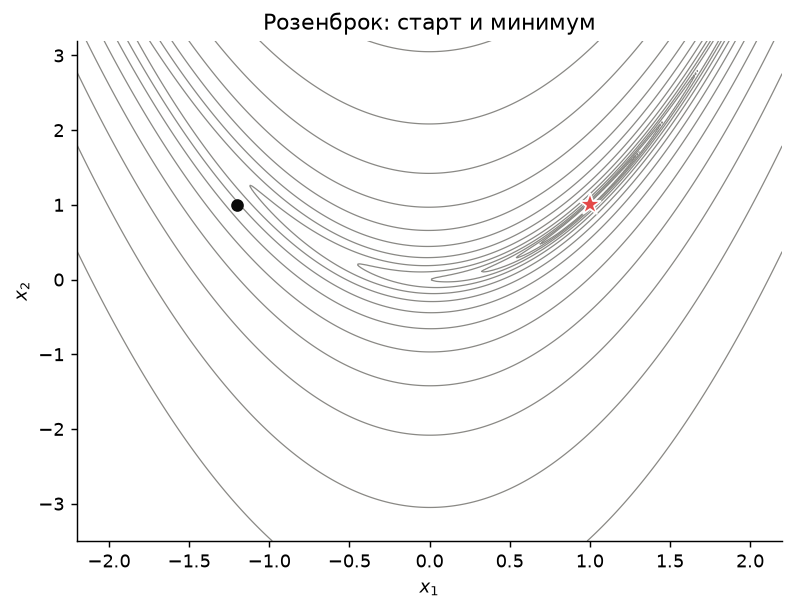

In [2]:
x = X0_ROSEN
print("f(x0) =", round(rosen(x), 2), "  grad =", rosen_grad(x).round(2), "  собственные числа гессиана:", np.linalg.eigvalsh(rosen_hess(x)).round(2))
plot_rosen_path([], ax=None).plot(*X0_ROSEN, "o", color=INK)
plt.title("Розенброк: старт и минимум"); plt.show()

**Задача Б. Подгонка синуса** (ДЗ 2, задача 2(б)). Данные генерируются тем же `default_rng(2026)` и в том же порядке, что в ноутбуке ДЗ, поэтому совпадают с ним точно. Модель $\varphi(t;x)=x_1\sin(x_2t+x_3)$, невязки $r_i=\varphi(t_i;x)-y_i$, цель $f=\tfrac12\lVert r\rVert^2$. Проверяем формулы $\nabla f=J^\top r$ и $\nabla^2f=J^\top J+\sum r_i\nabla^2r_i$ конечными разностями.

градиент: аналитический [   9.0231 -221.2442  -69.1056]  конечные разности [   9.0231 -221.2442  -69.1056]
гессиан:  max |аналитический - разностный| = 0.0
старт ДЗ 2 №1: [-1.863 -3.822  1.632]   всего стартов: 20


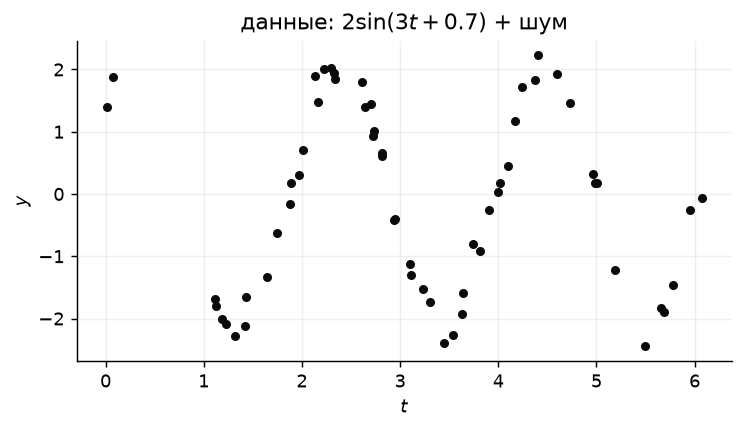

In [3]:
t, y, starts = sine_data()
resid, jac, f_s, grad_s, hess_s = sine_problem(t, y)
x = np.array([1.5, 2.8, 0.4]); h = 1e-6
g_fd = np.array([(f_s(x + h * e) - f_s(x - h * e)) / (2 * h) for e in np.eye(3)])
H_fd = np.array([(grad_s(x + h * e) - grad_s(x - h * e)) / (2 * h) for e in np.eye(3)])
print("градиент: аналитический", grad_s(x).round(4), " конечные разности", g_fd.round(4))
print("гессиан:  max |аналитический - разностный| =", np.abs(hess_s(x) - H_fd).max().round(5))
print("старт ДЗ 2 №1:", starts[0].round(3), "  всего стартов:", len(starts))
plt.figure(figsize=(6.5, 3.2)); plt.plot(t, y, "o", ms=4, color=INK); plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("данные: $2\\sin(3t+0.7)$ + шум"); plt.show()

**Задача В. Цепь без пола** (лекция 1, §7.3; лекция 4, демо (d)). $N=40$ грузов, $80$ переменных, энергия квадратична: $\nabla E=Hv+b$, $\nabla^2E=H=\operatorname{diag}(DK,DK)$. Проверяем, что `grad_E` — действительно градиент `energy`, и запоминаем точное решение `np.linalg.solve(H, -b)` — с ним будем сравнивать все методы.

In [4]:
energy, grad_E, H_chain, b_chain, v0_chain, unpack = make_chain(40)
v_test = np.random.default_rng(0).normal(size=80); h = 1e-6
g_fd = np.array([(energy(v_test + h * e) - energy(v_test - h * e)) / (2 * h) for e in np.eye(80)])
print("проверка градиента цепи: max |grad_E - разности| =", np.abs(grad_E(v_test) - g_fd).max().round(6))
v_star = np.linalg.solve(H_chain, -b_chain)
lam = np.linalg.eigvalsh(H_chain)
print(f"E* = {energy(v_star):.4f} (в конспекте 13.4417),  κ = {lam[-1] / lam[0]:.1f} (в конспекте 681),  L = {lam[-1]:.1f}")

проверка градиента цепи: max |grad_E - разности| = 1e-06
E* = 13.4417 (в конспекте 13.4417),  κ = 680.6 (в конспекте 681),  L = 279.6


## (a) Метод Ньютона на Розенброке

Разделы 2–3 конспекта. **Что проверяем.** Чистый Ньютон из $(-1.2,1)$ сходится за $7$ итераций до $\lVert\nabla f\rVert\le10^{-10}$; ошибки $2.2,\ 2.21,\ 4.18,\ 0.48,\ 0.056,\ 9.6\cdot10^{-6},\ 1.9\cdot10^{-11}$ — на итерации 2 ошибка *растёт* (точка улетает в $(0.76,-3.18)$), с пятой — обрыв. Отношения $C_k=\lVert e_{k+1}\rVert/\lVert e_k\rVert^2$ в хвосте — порядка $0.003$–$0.2$, много меньше теоретической оценки $M/2m\approx3000$.

In [5]:
x_n, k_n, path_n = newton(rosen_grad, rosen_hess, X0_ROSEN)
err_n = np.linalg.norm(path_n - 1, axis=1)
print(f"Ньютон: {k_n} итераций (в конспекте 7), x = {x_n}")
print(" k   x_k                     |e_k|      |e_{k+1}|/|e_k|^2   lambda(H(x_k))")
for k in range(len(path_n)):
    ratio = f"{err_n[k + 1] / err_n[k] ** 2:9.3f}" if k + 1 < len(path_n) and err_n[k] > 0 else "        -"
    lam = np.linalg.eigvalsh(rosen_hess(path_n[k]))
    print(f"{k:2d}  ({path_n[k, 0]: .5f}, {path_n[k, 1]: .5f})   {err_n[k]:.2e}   {ratio}      {lam[0]:8.2f} {lam[1]:9.1f}" + ("   <- ошибка выросла" if k > 0 and err_n[k] > err_n[k - 1] else ""))

Ньютон: 7 итераций (в конспекте 7), x = [1. 1.]
 k   x_k                     |e_k|      |e_{k+1}|/|e_k|^2   lambda(H(x_k))
 0  (-1.20000,  1.00000)   2.20e+00       0.456         23.63    1506.4
 1  (-1.17528,  1.38067)   2.21e+00       0.857          0.34    1306.9   <- ошибка выросла
 2  ( 0.76311, -3.17503)   4.18e+00       0.027        148.86    2022.0   <- ошибка выросла
 3  ( 0.76343,  0.58282)   4.80e-01       0.243          0.60     667.7
 4  ( 1.00000,  0.94403)   5.60e-02       0.003          4.78    1019.6
 5  ( 1.00000,  0.99999)   9.62e-06       0.200          0.40    1001.6
 6  ( 1.00000,  1.00000)   1.85e-11       0.000          0.40    1001.6
 7  ( 1.00000,  1.00000)   0.00e+00           -          0.40    1001.6


Гессиан положительно определён во всех семи точках пути — выброс итерации 2 не из-за седловой модели: просто в $x_1$ модель вытянута, и её минимум далеко от функции (конспект, §2.2, картинка 02).

**Демпфирование** (конспект, §3.4). То же направление $p_k$ из $\nabla^2f(x_k)\,p_k=-g_k$, но шаг $x_{k+1}=x_k+\alpha_kp_k$, где $\alpha_k$ выбирается по правилу Армихо: начать с $\alpha=1$ и делить пополам, пока не выполнится $f(x_k+\alpha p_k)\le f(x_k)+c\,\alpha\,g_k^\top p_k$, $c=10^{-4}$. Если $g^\top p\ge0$ (гессиан индефинитен), матрица сдвигается: $B_k=\nabla^2f(x_k)+\tau I$, $\tau=\lvert\lambda_{\min}\rvert+10^{-3}$ — на этом пути это не понадобится. Должны увидеть $22$ итерации: $f$ убывает на каждом шаге и выброса нет (ошибка по пути не превышает $2.21$ против $4.18$ у чистого Ньютона), зато обрыв начинается позже (вблизи минимума Армихо принимает $\alpha=1$, и метод снова чистый Ньютон).

демпфированный Ньютон: 22 итераций (в конспекте 22), x = [1. 1.];  f убывает на каждом шаге: True;  наибольшая ошибка по пути 2.208 (у чистого Ньютона 4.18)
ошибки: [2.200e+00 2.208e+00 1.942e+00 1.829e+00 1.711e+00 1.632e+00 1.565e+00 1.473e+00 1.335e+00 1.226e+00 1.078e+00
 9.376e-01 6.957e-01 5.893e-01 4.164e-01 2.919e-01 1.320e-01 7.126e-02 9.180e-03 1.173e-03 2.727e-06 1.351e-10
 0.000e+00]


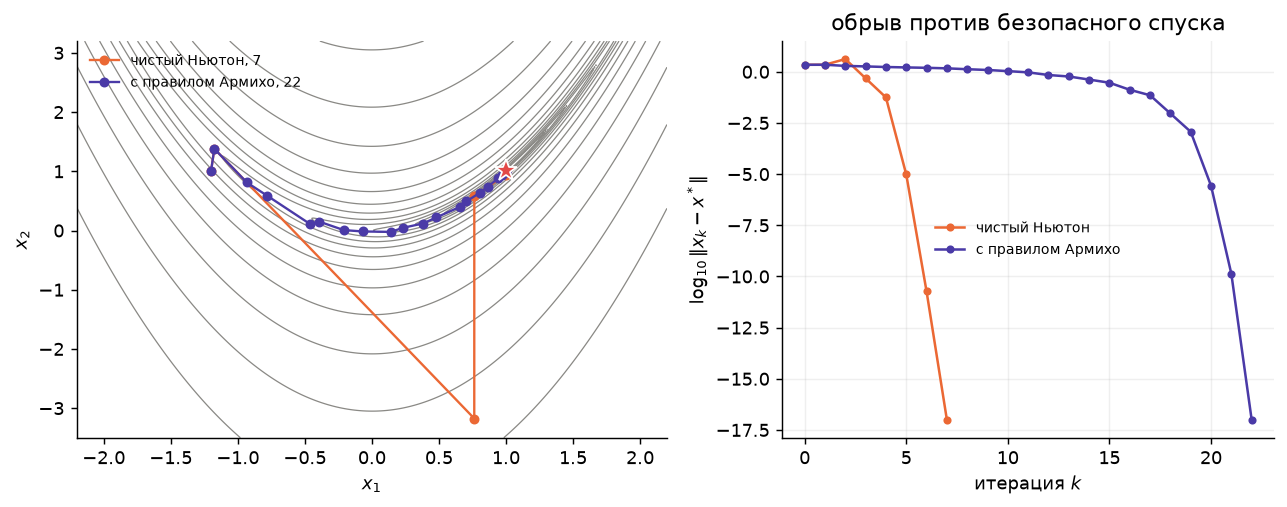

In [6]:
x_d, k_d, path_d = newton_damped(rosen, rosen_grad, rosen_hess, X0_ROSEN)
err_d = np.linalg.norm(path_d - 1, axis=1)
f_d = np.array([rosen(v) for v in path_d])
print(f"демпфированный Ньютон: {k_d} итераций (в конспекте 22), x = {x_d.round(8)};  f убывает на каждом шаге: {np.all(np.diff(f_d) < 0)};  наибольшая ошибка по пути {err_d.max():.3f} (у чистого Ньютона 4.18)")
print("ошибки:", np.array2string(err_d, precision=3, max_line_width=120))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={"width_ratios": [1.2, 1]})
plot_rosen_path([path_n, path_d], [f"чистый Ньютон, {k_n}", f"с правилом Армихо, {k_d}"], ax=ax1)
plot_errors([err_n, err_d], ["чистый Ньютон", "с правилом Армихо"], ax=ax2)
ax2.set_title("обрыв против безопасного спуска"); plt.tight_layout(); plt.show()

**Предскажите до запуска.** Чистый Ньютон стартует из $(2,2)$ — точки под параболой, где гессиан $\succ0$ с $\kappa\approx108$. Сколько будет итераций: больше или меньше семи? А из $(0,0)$, где функция почти квадратична вдоль $x_2$ ($\lambda=2$ и $200$)? Измените `START` и проверьте.

In [7]:
START = (2.0, 2.0)          # измените и перезапустите; ответ — в следующей ячейке
x, k, path = newton(rosen_grad, rosen_hess, START)
print(f"из {START}: {k} итераций, ошибки {np.array2string(np.linalg.norm(path - 1, axis=1), precision=2)}")

из (2.0, 2.0): 5 итераций, ошибки [1.41e+00 3.15e+00 9.90e-01 2.76e-03 1.52e-06 6.45e-15]


Ответ: из $(2,2)$ — $5$ итераций (ошибка $1.41\to3.15\to0.99\to0.003\to\dots$: снова выброс, затем обрыв), из $(0,0)$ — $2$. Число итераций Ньютона не читается по $\kappa$ и даже по расстоянию до минимума: решает то, насколько квадратичная модель похожа на функцию вдоль пути.

## (b) BFGS: кривизна из разности градиентов

Раздел 4 конспекта, упражнение 11.5. **Что проверяем.** На квадратичной $f=\tfrac12(x_1^2+50x_2^2)$ из $(50,1)$ с точным шагом BFGS восстанавливает обратный гессиан за два обновления: $H_2=Q^{-1}=\operatorname{diag}(1,\,0.02)$ точно, и $x_2=0$. Для сравнения: спуск с точным шагом на той же задаче — $567$ итераций (лекция 4).

In [8]:
Q = np.diag([1.0, 50.0])
f_q, grad_q = (lambda x: 0.5 * x @ Q @ x), (lambda x: Q @ x)
x_q, k_q, path_q, _ = bfgs(f_q, grad_q, [50.0, 1.0], tol=1e-10, Q=Q)
print(f"BFGS с точным шагом: {k_q} итерации, x = {x_q}")

# восстанавливаем H_k по пути, как в упражнении 11.5
H = np.eye(2)
for k in range(len(path_q) - 1):
    s = path_q[k + 1] - path_q[k]; y_ = Q @ s; rho = 1 / (s @ y_); I = np.eye(2)
    print(f"шаг {k}: s = {s.round(4)}, y = {y_.round(4)}, s^T y = {s @ y_:.4f} > 0")
    H = (I - rho * np.outer(s, y_)) @ H @ (I - rho * np.outer(y_, s)) + rho * np.outer(s, s)
    print(f"        H_{k + 1} =\n{H.round(6)}   проверка секущего уравнения H y = s: {np.allclose(H @ y_, s)}")
print("Q^{-1} =\n", np.linalg.inv(Q))
assert np.allclose(H, np.linalg.inv(Q), atol=1e-10)

BFGS с точным шагом: 2 итерации, x = [-7.10542736e-15  1.22124533e-15]
шаг 0: s = [-1.9608 -1.9608], y = [ -1.9608 -98.0392], s^T y = 196.0784 > 0
        H_1 =
[[ 1.941945 -0.018839]
 [-0.018839  0.020377]]   проверка секущего уравнения H y = s: True
шаг 1: s = [-48.0392   0.9608], y = [-48.0392  48.0392], s^T y = 2353.9216 > 0
        H_2 =
[[1.   0.  ]
 [0.   0.02]]   проверка секущего уравнения H y = s: True
Q^{-1} =
 [[1.   0.  ]
 [0.   0.02]]


**Розенброк.** Наш BFGS с $H_0=I$ и правилом Армихо должен дать $34$ итерации и $54$ вычисления $f$ (до $\lVert\nabla f\rVert\le10^{-6}$); `scipy.optimize.minimize(method="BFGS")` с тем же допуском — $33$ итерации и $40$ вычислений (к Армихо там добавлено условие кривизны Вольфе, §4.3, и шаги принимаются экономнее). `L-BFGS-B` — $36$. Хвост отношений $\lVert e_{k+1}\rVert/\lVert e_k\rVert$ у BFGS стремится к нулю, но не квадратично — сверхлинейная сходимость. На графике (картинка 10 конспекта) спуск — прямая, BFGS — загибается, Ньютон — обрыв; спуск занимает секунды: $13\,756$ итераций.

свой BFGS:      34 итераций, 54 вычислений f (в конспекте 34 и 54), x = [1. 1.]
scipy BFGS:     33 итераций, 40 вычислений f (в конспекте 33 и 40)
scipy L-BFGS-B: 36 итераций, 44 вычислений f (в конспекте 36)
хвост |e_(k+1)|/|e_k| у BFGS: [0.4656 0.1422 0.3047 0.0159 0.0322 0.0137]  (квадратичная дала бы ~1e-5)


спуск с правилом Армихо: 13756 итераций (в конспекте 13 756), 0.43 с


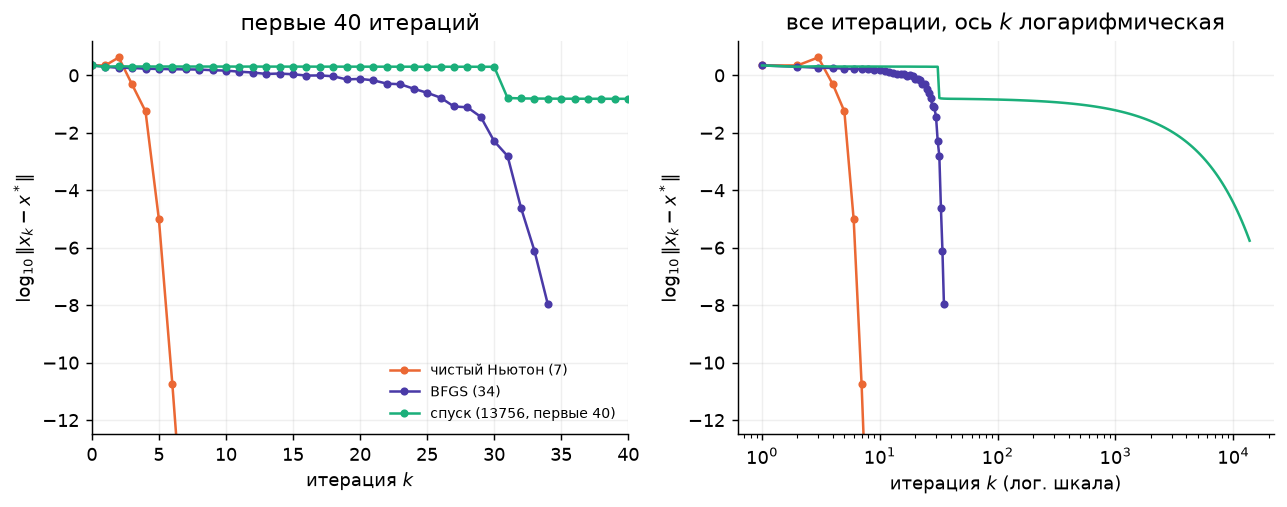

In [9]:
x_b, k_b, path_b, nfev_b = bfgs(rosen, rosen_grad, X0_ROSEN)
err_b = np.linalg.norm(path_b - 1, axis=1)
print(f"свой BFGS:      {k_b} итераций, {nfev_b} вычислений f (в конспекте 34 и 54), x = {x_b.round(7)}")
r_bfgs = minimize(rosen, X0_ROSEN, jac=rosen_grad, method="BFGS", options={"gtol": 1e-6})
r_lbfgs = minimize(rosen, X0_ROSEN, jac=rosen_grad, method="L-BFGS-B", options={"gtol": 1e-6})
print(f"scipy BFGS:     {r_bfgs.nit} итераций, {r_bfgs.nfev} вычислений f (в конспекте 33 и 40)")
print(f"scipy L-BFGS-B: {r_lbfgs.nit} итераций, {r_lbfgs.nfev} вычислений f (в конспекте 36)")
print("хвост |e_(k+1)|/|e_k| у BFGS:", np.array2string(err_b[-6:] / err_b[-7:-1], precision=4), " (квадратичная дала бы ~1e-5)")

t0 = time.perf_counter(); x_g, k_g, path_g = gd(rosen, rosen_grad, X0_ROSEN); t_gd = time.perf_counter() - t0
err_g = np.linalg.norm(path_g - 1, axis=1)
print(f"спуск с правилом Армихо: {k_g} итераций (в конспекте 13 756), {t_gd:.2f} с")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
plot_errors([err_n, err_b, err_g[:41]], [f"чистый Ньютон ({k_n})", f"BFGS ({k_b})", f"спуск ({k_g}, первые 40)"], ax=ax1)
ax1.set(xlim=(0, 40), ylim=(-12.5, 1.2), title="первые 40 итераций")
plot_errors([err_n, err_b, err_g], ax=ax2, logx=True); ax2.set(ylim=(-12.5, 1.2), title="все итерации, ось $k$ логарифмическая")
plt.tight_layout(); plt.show()

## (c) Гаусс–Ньютон на синусе из ДЗ 2

Раздел 5 конспекта, упражнение 11.7. **Что проверяем.** Из старта $(1,3,0)$: Гаусс–Ньютон — $7$ итераций к $x^\ast=(2.1014,\,2.9967,\,0.7003)$, $f^\ast=1.1393$; спуск с backtracking — $731$ итерация туда же; чистый Ньютон — к стационарной точке с $x_1=0$ (нулевая амплитуда, $f=\tfrac12\lVert y\rVert^2\approx64$). В $x^\ast$ собственные числа $J^\top J$ и полного гессиана отличаются меньше чем на $2\,\%$ — невязки малы, и отброшенный член $\sum r_i\nabla^2r_i$ почти не влияет.

In [10]:
x_gn, k_gn, path_gn = gauss_newton(resid, jac, X0_SINE)
x_gds, k_gds, path_gds = gd(f_s, grad_s, X0_SINE)
x_nw, k_nw, path_nw = newton(grad_s, hess_s, X0_SINE, tol=1e-6)
print(f"Гаусс–Ньютон: {k_gn} итераций (в конспекте 7),  x* = {x_gn.round(4)},  f* = {f_s(x_gn):.4f} (в конспекте 1.1393)")
print(f"спуск:        {k_gds} итераций (в конспекте 731), x  = {x_gds.round(4)},  f  = {f_s(x_gds):.4f}")
print(f"Ньютон:       {k_nw} итераций,                 x  = {x_nw.round(4)},  f  = {f_s(x_nw):.1f},  |grad f| = {np.linalg.norm(grad_s(x_nw)):.1e}  <- стационарная точка с x1 = 0")
lamJ, lamH = np.linalg.eigvalsh(jac(x_gn).T @ jac(x_gn)), np.linalg.eigvalsh(hess_s(x_gn))
print("собственные числа J^T J в x*:", lamJ.round(2), "  полного гессиана:", lamH.round(2), f"  относительная разница до {np.max(np.abs(lamJ - lamH) / lamH):.1%}")
err_gn = np.linalg.norm(path_gn - x_gn, axis=1)
print("ошибки Гаусса–Ньютона:", np.array2string(err_gn, precision=6), " отношения:", np.array2string(err_gn[1:] / err_gn[:-1], precision=3))

Гаусс–Ньютон: 7 итераций (в конспекте 7),  x* = [2.1014 2.9967 0.7003],  f* = 1.1393 (в конспекте 1.1393)
спуск:        731 итераций (в конспекте 731), x  = [2.1014 2.9967 0.7003],  f  = 1.1393
Ньютон:       9 итераций,                 x  = [-0.      3.8658 -6.4737],  f  = 64.4,  |grad f| = 1.2e-09  <- стационарная точка с x1 = 0
собственные числа J^T J в x*: [  17.57   31.05 1935.56]   полного гессиана: [  17.89   31.12 1927.31]   относительная разница до 1.8%
ошибки Гаусса–Ньютона: [1.305161e+00 8.297955e-01 4.548437e-01 4.714325e-02 1.842978e-03
 3.304049e-05 7.004102e-07 0.000000e+00]  отношения: [0.636 0.548 0.104 0.039 0.018 0.021 0.   ]


Почему Ньютон уходит в нуль: при $x_1=0$ столбцы $J$ для частоты и фазы нулевые, а $\nabla f=J^\top r$ зануляется, когда $\sin(x_2t+x_3)\perp y$ — таких стационарных точек бесконечно много, и полный гессиан вдали от решения ведёт к ним. У Гаусса–Ньютона $J^\top J\succeq0$, и его шаг — всегда направление спуска: проверяем знак $g^\top p$ вдоль пути обоих методов.

In [11]:
for name, path, use_gn in (("Гаусс–Ньютон", path_gn, True), ("Ньютон", path_nw, False)):
    signs = []
    for x in path[:-1]:
        g = grad_s(x)
        p = np.linalg.lstsq(jac(x), -resid(x), rcond=None)[0] if use_gn else -np.linalg.solve(hess_s(x), g)
        signs.append(g @ p < 0)
    print(f"{name:13s}: направление спуска на итерациях {np.array(signs).astype(int)}  (1 — спуск, 0 — подъём)")
print("Левенберг–Марквардт (scipy.optimize.least_squares, method='lm'):", end=" ")
r_lm = least_squares(resid, X0_SINE, jac=jac, method="lm")
print(f"{r_lm.nfev} вычислений невязки, x = {r_lm.x.round(4)}")

Гаусс–Ньютон : направление спуска на итерациях [1 1 1 1 1 1 1]  (1 — спуск, 0 — подъём)
Ньютон       : направление спуска на итерациях [0 1 1 0 0 0 0 0 0]  (1 — спуск, 0 — подъём)
Левенберг–Марквардт (scipy.optimize.least_squares, method='lm'): 7 вычислений невязки, x = [2.1014 2.9967 0.7003]


**Локальность никуда не делась.** Запускаем демпфированный Гаусс–Ньютон из 20 стартов ДЗ 2 (те же `starts`): к глобальному $f^\ast=1.1393$ должны прийти $12$ из $20$, остальные — к локальным минимумам с другой частотой. Каждый старт стоит десятки итераций, а не сотни — мультистарт из ДЗ 2 становится дешёвым.

к глобальному минимуму пришли 12 из 20 стартов (в конспекте 12);  итераций: медиана 12, максимум 200
итоговые f по стартам: [ 1.14  1.14  1.14  1.14  1.14  1.14  1.14  1.14  1.14  1.14  1.14  1.14 60.14 61.5  61.5  61.5  61.69 64.22 64.25
 64.25]


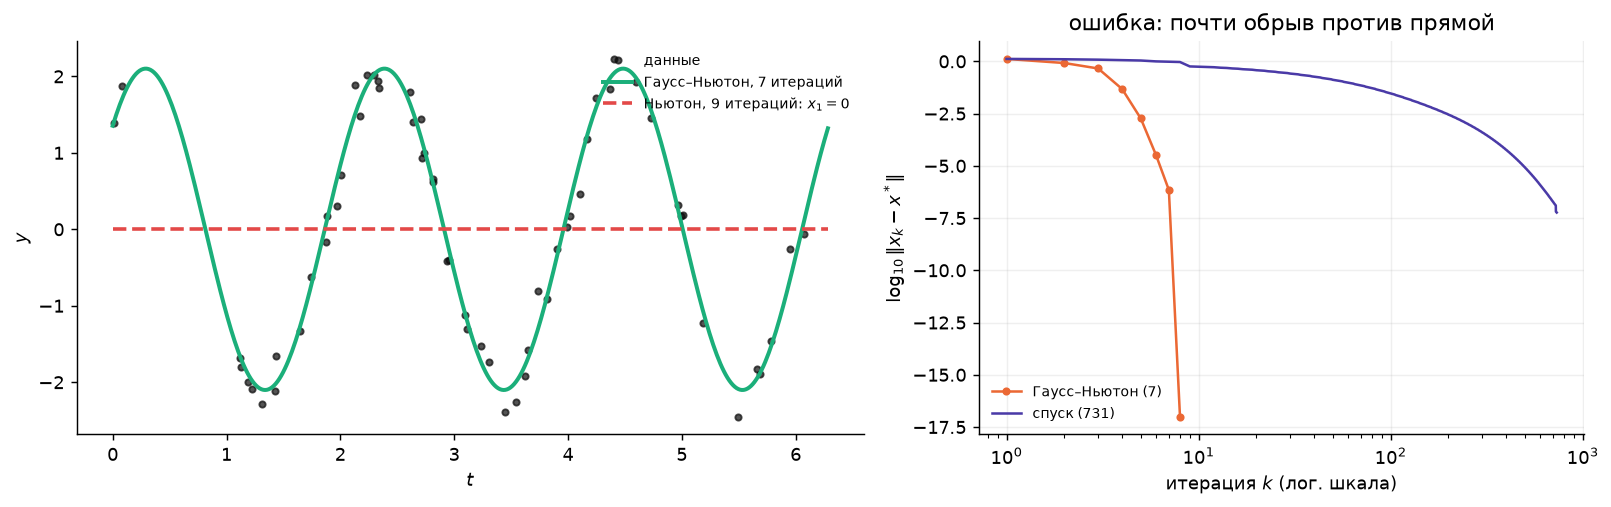

In [12]:
finals = []
for s0 in starts:
    xs, ks, _ = gauss_newton(resid, jac, s0, damped=True, maxit=200)
    finals.append((f_s(xs), ks))
finals = np.array(finals)
n_global = np.sum(np.abs(finals[:, 0] - f_s(x_gn)) < 1e-6)
print(f"к глобальному минимуму пришли {n_global} из {len(starts)} стартов (в конспекте 12);  итераций: медиана {np.median(finals[:, 1]):.0f}, максимум {finals[:, 1].max():.0f}")
print("итоговые f по стартам:", np.array2string(np.sort(finals[:, 0]), precision=2, max_line_width=120))

tt = np.linspace(0, 2 * np.pi, 400)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.0), gridspec_kw={"width_ratios": [1.3, 1]})
ax1.plot(t, y, "o", ms=3.5, color=INK, alpha=0.7, label="данные")
ax1.plot(tt, x_gn[0] * np.sin(x_gn[1] * tt + x_gn[2]), color=AQUA, lw=2.2, label=f"Гаусс–Ньютон, {k_gn} итераций")
ax1.plot(tt, x_nw[0] * np.sin(x_nw[1] * tt + x_nw[2]), "--", color=RED, lw=2, label=f"Ньютон, {k_nw} итераций: $x_1=0$")
ax1.set(xlabel="$t$", ylabel="$y$"); ax1.legend(fontsize=8, loc="upper right"); ax1.grid(False)
plot_errors([err_gn, np.linalg.norm(path_gds - x_gn, axis=1)], [f"Гаусс–Ньютон ({k_gn})", f"спуск ({k_gds})"], ax=ax2, logx=True)
ax2.set_title("ошибка: почти обрыв против прямой"); plt.tight_layout(); plt.show()

## (d) Биография цепи

Раздел 6 конспекта, упражнение 11.9. **Что проверяем** на цепи $N=40$ (старт — прямая между концами, останов $\lVert\nabla E\rVert\le10^{-6}$): спуск с шагом $1/L$ — $10\,575$ итераций (лекция 4); Ньютон — одна итерация, то есть `np.linalg.solve`; BFGS с точным шагом — $20$ итераций (не больше числа различных собственных чисел $H$, их у $\operatorname{diag}(DK,DK)$ ровно $N=40$; здесь из-за симметрии старта хватает $N/2$); `L-BFGS-B` с памятью 5 — $75$.

In [13]:
L = np.linalg.eigvalsh(H_chain)[-1]
t0 = time.perf_counter(); v_gd, k_gd, _ = gd(energy, grad_E, v0_chain, alpha=1 / L); t_gd = time.perf_counter() - t0
v_nt = v0_chain - np.linalg.solve(H_chain, grad_E(v0_chain))                       # один шаг Ньютона
v_bq, k_bq, _, _ = bfgs(energy, grad_E, v0_chain, Q=H_chain)
r_l = minimize(energy, v0_chain, jac=grad_E, method="L-BFGS-B", options={"gtol": 1e-6, "maxcor": 5})
print(f"спуск, шаг 1/L:        {k_gd} итераций ({t_gd:.2f} с; в конспекте 10 575),  |v - v*| = {np.linalg.norm(v_gd - v_star):.1e}")
print(f"Ньютон:                1 итерация,                              |v - v*| = {np.linalg.norm(v_nt - v_star):.1e}")
print(f"BFGS, точный шаг:      {k_bq} итераций (в конспекте 20),              |v - v*| = {np.linalg.norm(v_bq - v_star):.1e}")
print(f"L-BFGS-B, память 5:    {r_l.nit} итераций (в конспекте 75),              |v - v*| = {np.linalg.norm(r_l.x - v_star):.1e}")
print(f"различных собственных чисел H: {len(np.unique(np.linalg.eigvalsh(H_chain).round(8)))}  (N = 40)")

спуск, шаг 1/L:        10575 итераций (0.07 с; в конспекте 10 575),  |v - v*| = 2.4e-06
Ньютон:                1 итерация,                              |v - v*| = 2.9e-14
BFGS, точный шаг:      20 итераций (в конспекте 20),              |v - v*| = 6.1e-14
L-BFGS-B, память 5:    75 итераций (в конспекте 75),              |v - v*| = 2.4e-04
различных собственных чисел H: 40  (N = 40)


**Как BFGS ломается с одним лишь правилом Армихо.** Тот же BFGS, длина шага — только по Армихо, от $\alpha=1$ вниз. На цепи он не сходится за $2\,000$ итераций (и за $10\,000$ тоже — проверьте, подняв `maxit`): крошечные принятые шаги дают пары $(s,y)$, которые портят $H_k$, направление $p_k$ раздувается, шаг снова крошечный. Печатаем длины принятых шагов в конце — они порядка $10^{-9}$: $\alpha$ опустился до $2^{-35}$. Условие кривизны Вольфе (§4.3) это чинит: SciPy с ним сходится за $68$ итераций.

In [14]:
v_bb, k_bb, path_bb, nfev_bb = bfgs(energy, grad_E, v0_chain, maxit=2000)
steps = np.linalg.norm(np.diff(path_bb, axis=0), axis=1)
print(f"BFGS с backtracking: {'НЕ сошёлся' if k_bb >= 2000 else 'сошёлся'} за {k_bb} итераций, {nfev_bb} вычислений E ({nfev_bb / max(k_bb, 1):.0f} на итерацию);  |grad E| = {np.linalg.norm(grad_E(v_bb)):.1e}")
print("длины последних пяти принятых шагов |s_k|:", np.array2string(steps[-5:], formatter={"float_kind": "{:.1e}".format}), "  (2^-35 от направления)")
r_sb = minimize(energy, v0_chain, jac=grad_E, method="BFGS", options={"gtol": 1e-6})
print(f"scipy BFGS (Армихо + условие Вольфе): {r_sb.nit} итераций (в конспекте 68), {r_sb.nfev} вычислений E")

BFGS с backtracking: НЕ сошёлся за 2000 итераций, 66971 вычислений E (33 на итерацию);  |grad E| = 1.5e-06
длины последних пяти принятых шагов |s_k|: [0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00]   (2^-35 от направления)
scipy BFGS (Армихо + условие Вольфе): 68 итераций (в конспекте 68), 85 вычислений E


**Биография по $N$.** Для $N=10,20,40,80$ — число итераций спуска, BFGS с точным шагом и L-BFGS; Ньютон всегда $1$. Спуск растёт как $\kappa\sim N^2$, BFGS — как $N/2$, L-BFGS — примерно как $N$. Картинка 12 конспекта продолжает таблицу до $N=160$ (спуск там — $155\,943$ итерации и $10$ секунд).

In [15]:
print(" N    κ        спуск 1/L   BFGS точный   L-BFGS m=5   Ньютон")
for N_ in (10, 20, 40, 80):
    e_, g_, H_, b_, v0_, _ = make_chain(N_)
    lam_ = np.linalg.eigvalsh(H_)
    _, kg_, _ = gd(e_, g_, v0_, alpha=1 / lam_[-1], maxit=100_000)
    _, kb_, _, _ = bfgs(e_, g_, v0_, Q=H_)
    rl_ = minimize(e_, v0_, jac=g_, method="L-BFGS-B", options={"gtol": 1e-6, "maxcor": 5})
    print(f"{N_:3d}  {lam_[-1] / lam_[0]:7.1f}   {kg_:9d}   {kb_:11d}   {rl_.nit:10d}        1")

 N    κ        спуск 1/L   BFGS точный   L-BFGS m=5   Ньютон
 10     48.4         779             5           12        1
 20    178.1        2825            10           26        1
 40    680.6       10575            20           75        1


 80   2658.4       40388            40          146        1


Одна и та же задача: $10\,575\to75\to20\to1$. Чем больше кривизны знает метод, тем меньше итераций — и тем дороже каждая: $O(n)$ у спуска, $O(mn)$ у L-BFGS, $O(n^2)$ у BFGS, $O(n^3)$ у Ньютона. При $N=10^5$ из таблицы останутся только первые два.

## Шпаргалка

| Что | Формула | Где в конспекте |
|---|---|---|
| одна формула лекции | $x_{k+1}=x_k-\alpha_kB_k^{-1}g_k$: спуск $B_k=I$, Ньютон $\nabla^2f$, BFGS $H_k^{-1}$, Гаусс–Ньютон $J^\top J$ | введение, §6 |
| квадратичная модель и шаг Ньютона | $m_k(p)=f_k+g_k^\top p+\tfrac12p^\top\nabla^2f(x_k)\,p$; $\nabla^2f(x_k)\,p_k=-g_k$ — минимум модели и нуль линеаризованного градиента | §2.1–2.2, часть (a) |
| аффинная инвариантность | при $x=Au$ шаг тот же: $A\tilde p=p$; поэтому $\kappa$ Ньютону безразлично | §2.2 |
| квадратичная сходимость | $\|e_{k+1}\|\le\frac{M}{2m}\|e_k\|^2$, $M$ — липшицева константа гессиана, $m=\lambda_{\min}$; цифры удваиваются | §3.1–3.2, часть (a) |
| демпфирование | $x_{k+1}=x_k+\alpha_kp_k$, Армихо: $f(x_k+\alpha p_k)\le f(x_k)+c\,\alpha\,g_k^\top p_k$, $c=10^{-4}$, от $\alpha=1$ пополам; вблизи минимума $\alpha=1$ | §3.4, часть (a) |
| седловая модель | $g^\top p=-g^\top(\nabla^2f)^{-1}g<0$ гарантировано лишь при $\nabla^2f\succ0$; иначе $B_k=\nabla^2f+\tau I$, $\tau>\lvert\lambda_{\min}\rvert$ | §3.4 |
| секущее уравнение | $B_{k+1}s_k=y_k$, $s_k=x_{k+1}-x_k$, $y_k=g_{k+1}-g_k$ | §4.2 |
| BFGS для $H=B^{-1}$ | $H_{k+1}=(I-\rho sy^\top)H_k(I-\rho ys^\top)+\rho ss^\top$, $\rho=1/y^\top s$; $\succ0$ сохраняется при $s^\top y>0$ (условие кривизны; его гарантирует условие Вольфе) | §4.3, часть (b) |
| L-BFGS | хранит $m$ последних пар $(s,y)$, $O(mn)$ памяти и операций | §4.5, часть (d) |
| МНК: градиент и гессиан | $f=\tfrac12\|r\|^2$: $\nabla f=J^\top r$, $\nabla^2f=J^\top J+\sum r_i\nabla^2r_i$ | §5.1, часть (c) |
| Гаусс–Ньютон | $J^\top Jp=-J^\top r$ — линейный МНК $\min\|Jp+r\|$ на каждом шаге; всегда спуск | §5.2, часть (c) |
| Левенберг–Марквардт | $(J^\top J+\lambda I)p=-J^\top r$ — штраф $\lambda\lVert p\rVert^2$ за длину шага; $\lambda$ меняется по отношению выигрыша $\rho$; `scipy.optimize.least_squares(method="lm")` | §5.3 |

Три вещи, которые легко перепутать:

1. **Стационарная точка $\ne$ минимум, и Ньютон этого не проверяет.** На синусе из $(1,3,0)$ он честно сошёлся — к точке с нулевой амплитудой. После любого ньютоновского метода смотрите собственные числа гессиана (лекция 4, §3).
2. **Квадратичная $\ne$ сверхлинейная.** У BFGS отношения $\|e_{k+1}\|/\|e_k\|$ стремятся к нулю ($0.3,\ 0.016,\ 0.03,\ 0.014,\ 0.012$), но у Ньютона на тех же итерациях было бы $10^{-5}$. На графике: загиб против обрыва.
3. **Гаусс–Ньютон $\ne$ Ньютон.** Отброшен член $\sum r_i\nabla^2r_i$; при малых невязках это почти ничего не стоит, а при больших — Гаусс–Ньютон сходится линейно, зато никогда не идёт вверх.